In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from PIL import Image

# --- Configurations ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 32
num_epochs = 10
learning_rate = 1e-4
num_classes = 2  # Tp vs Au
data_dir = "/content/drive/MyDrive/CASIA2.0_revised_corrected/casia"

# --- Dataset preparation ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# -*- coding: utf-8 -*-

### AJOUT : Installation des dépendances manquantes ###
!pip install -q thop torchmetrics timm

import os
import torch
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report
import timm
import matplotlib.pyplot as plt

# Imports nécessaires pour l'analyse
from thop import profile
from torchmetrics.classification import MulticlassF1Score

# --- Dataset ---
class CASIADataset(torch.utils.data.Dataset):
    def __init__(self, root_tp, root_au, transform=None):
        valid_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.tif']
        self.tp_images = [(os.path.join(root_tp, img), 1) for img in os.listdir(root_tp) if os.path.splitext(img)[1].lower() in valid_exts]
        self.au_images = [(os.path.join(root_au, img), 0) for img in os.listdir(root_au) if os.path.splitext(img)[1].lower() in valid_exts]
        self.data = self.tp_images + self.au_images
        self.transform = transform
    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        try: image = Image.open(img_path).convert('RGB')
        except: image = Image.new('RGB', (224, 224)) # Gère les images corrompues
        if self.transform: image = self.transform(image)
        return image, label
    def __len__(self): return len(self.data)

# --- Configuration ---
# Monter Google Drive (si nécessaire, exécutez dans une cellule séparée)
# from google.colab import drive
# drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/CASIA2.0_revised_corrected/casia'
tp_dir = os.path.join(data_dir, 'Tp')
au_dir = os.path.join(data_dir, 'Au')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224

# ===================================================================
# MODIFICATION : Changer le nom du modèle pour utiliser Swin Transformer
# ===================================================================
MODEL_NAME = 'swin_tiny_patch4_window7_224'
# ===================================================================

NUM_CLASSES = 2
BATCH_SIZE = 32
LEARNING_RATE = 1e-4 # Les transformers préfèrent souvent des taux d'apprentissage plus faibles
NUM_EPOCHS = 5

# --- Transformations et Données ---
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
full_dataset = CASIADataset(tp_dir, au_dir, transform=transform)
# Créer une permutation reproductible pour les splits
np.random.seed(42)
indices = np.random.permutation(len(full_dataset))
train_size = int(0.7 * len(full_dataset)); val_size = int(0.15 * len(full_dataset))
train_indices, val_indices, test_indices = indices[:train_size], indices[train_size:train_size+val_size], indices[train_size+val_size:]
train_loader = DataLoader(Subset(full_dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_indices), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(Subset(full_dataset, test_indices), batch_size=BATCH_SIZE, shuffle=False)

# --- Modèle, Perte et Optimiseur ---
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Boucle d'Entraînement ---
print(f"Début de l'entraînement du modèle {MODEL_NAME} sur {device}...")
for epoch in range(NUM_EPOCHS):
    model.train(); running_loss, correct, total = 0, 0, 0
    # Utiliser tqdm pour une barre de progression
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Training]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(); outputs = model(images); loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item(); _, predicted = outputs.max(1); total += labels.size(0); correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': running_loss/total, 'acc': 100.*correct/total})
    train_loss = running_loss/len(train_loader); train_acc = 100.*correct/total

    model.eval(); val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images); loss = criterion(outputs, labels)
            val_loss += loss.item(); _, predicted = outputs.max(1); total += labels.size(0); correct += predicted.eq(labels).sum().item()
    val_loss_epoch = val_loss/len(val_loader); val_acc = 100.*correct/total
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss_epoch:.4f}, Val Acc: {val_acc:.2f}%")

# --- Test sur le jeu de données de test ---
model.eval(); all_preds, all_labels = [], [];
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(images.to(device)); _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy()); all_labels.extend(labels.cpu().numpy())
print("\n--- Test Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=["Authentic", "Tampered"], digits=4, zero_division=0))


### ANALYSE FINALE POUR LE TABLEAU COMPARATIF ###
print("\n" + "="*50 + f"\n--- ANALYSE DU MODÈLE '{MODEL_NAME}' ---\n" + "="*50)

# 1. Backbone utilisé
print(f"-> Backbone                      : {MODEL_NAME}")

# 2. Calcul des Paramètres (Totaux)
params_total = sum(p.numel() for p in model.parameters())
print(f"-> Nombre de Paramètres Totaux (M) : {params_total / 1e6:.2f} M")

# 3. Calcul des GFLOPs
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
# thop peut avoir des soucis avec certains ops de Swin, si ça échoue, on le signale
try:
    macs, _ = profile(model, inputs=(dummy_input,), verbose=False)
    gflops = (macs * 2) / 1e9
    print(f"-> Complexité (GFLOPs)             : {gflops:.2f}")
except Exception as e:
    print(f"-> Complexité (GFLOPs)             : Erreur lors du calcul avec thop - {e}")


# 4. Calcul du F1-Score
f1 = MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(device)
model.eval()
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Calcul du F1-Score"):
        outputs = model(imgs.to(device))
        f1.update(outputs.argmax(1), lbls.to(device))
final_f1_score = f1.compute().item()
print(f"-> F1-Score (Macro)                : {final_f1_score:.4f}")

print("="*50 + "\nAnalyse terminée.")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Début de l'entraînement du modèle swin_tiny_patch4_window7_224 sur cuda...


Epoch 1/5 [Training]:  82%|████████▏ | 207/253 [1:09:09<14:49, 19.33s/it, loss=0.0151, acc=76]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Epoch [1/20] Train Loss: 0.6005, Train Acc: 67.76%, Val Loss: 0.5591, Val Acc: 70.67%
Epoch [2/20] Train Loss: 0.5618, Train Acc: 70.49%, Val Loss: 0.5575, Val Acc: 72.46%
Epoch [3/20] Train Loss: 0.5327, Train Acc: 72.69%, Val Loss: 0.5399, Val Acc: 71.36%
Epoch [4/20] Train Loss: 0.4983, Train Acc: 75.02%, Val Loss: 0.5492, Val Acc: 70.27%
Epoch [5/20] Train Loss: 0.4767, Train Acc: 76.37%, Val Loss: 0.5476, Val Acc: 72.06%
Epoch [6/20] Train Loss: 0.4355, Train Acc: 79.06%, Val Loss: 0.5724, Val Acc: 70.61%
Epoch [7/20] Train Loss: 0.4091, Train Acc: 79.87%, Val Loss: 0.5719, Val Acc: 72.58%
Epoch [8/20] Train Loss: 0.3776, Train Acc: 81.84%, Val Loss: 0.5776, Val Acc: 72.69%
Epoch [9/20] Train Loss: 0.3541, Train Acc: 83.00%, Val Loss: 0.6122, Val Acc: 71.19%
Epoch [10/20] Train Loss: 0.3358, Train Acc: 83.99%, Val Loss: 0.6031, Val Acc: 72.52%
Epoch [11/20] Train Loss: 0.3149, Train Acc: 84.92%, Val Loss: 0.6934, Val Acc: 71.59%
Epoch [12/20] Train Loss: 0.3051, Train Acc: 86.07%,

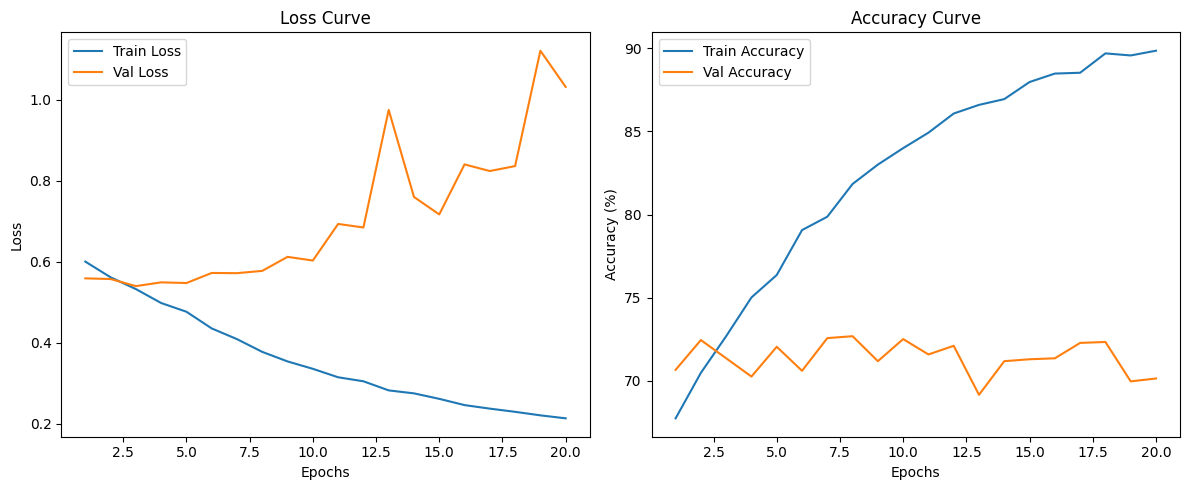

In [ ]:


# Dataset
class CASIADataset(torch.utils.data.Dataset):
    def __init__(self, root_tp, root_au, transform=None):
        valid_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.tif']
        self.tp_images = [(os.path.join(root_tp, img), 1)
                          for img in os.listdir(root_tp)
                          if os.path.splitext(img)[1].lower() in valid_exts]

        self.au_images = [(os.path.join(root_au, img), 0)
                          for img in os.listdir(root_au)
                          if os.path.splitext(img)[1].lower() in valid_exts]

        self.data = self.tp_images + self.au_images
        self.transform = transform

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # image corrompue => image noire
            image = Image.new('RGB', (224, 224))
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.data)

# Paths
data_dir = '/content/drive/MyDrive/CASIA2.0_revised_corrected/casia'
   # <-- modifie ici
tp_dir = os.path.join(data_dir, 'Tp')
au_dir = os.path.join(data_dir, 'Au')

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # valeurs standard ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Dataset
full_dataset = CASIADataset(tp_dir, au_dir, transform=transform)

# Split dataset (shuffle)
from torch.utils.data import Subset
import numpy as np

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

indices = np.random.permutation(len(full_dataset))
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Device (CPU ici)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Model ---
num_classes = 2
model = timm.create_model('resnet18', pretrained=True, num_classes=num_classes)
model = model.to(device)

# --- Loss and optimizer ---
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- Training loop ---
num_epochs = 20
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100. * correct / total)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}%, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.2f}%")

# --- Test ---
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nTest classification report:\n", classification_report(all_labels, all_preds, target_names=["Au", "Tp"]))

# --- Plot results ---
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy Curve")

plt.tight_layout()
plt.show()


In [ ]:
print("\nTest classification report:\n", classification_report(all_labels, all_preds, target_names=["Au", "Tp"]))



Test classification report:
               precision    recall  f1-score   support

          Au       0.78      0.74      0.76      1110
          Tp       0.58      0.62      0.60       623

    accuracy                           0.70      1733
   macro avg       0.68      0.68      0.68      1733
weighted avg       0.71      0.70      0.70      1733



In [ ]:
!ls /content/drive/MyDrive/CASIA2.0_revised_corrected/casia


Au  au_list.txt  Gt  Tp  tp_list.txt


In [ ]:
print(device)
print(torch.cuda.is_available())


cpu
False
